# Iris Flower Classification
**Track:** Data Science &nbsp;|&nbsp; **Task 1**

**Objective:** Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load the dataset

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.drop(columns=['target'], inplace=True)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Shape: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Visualisations

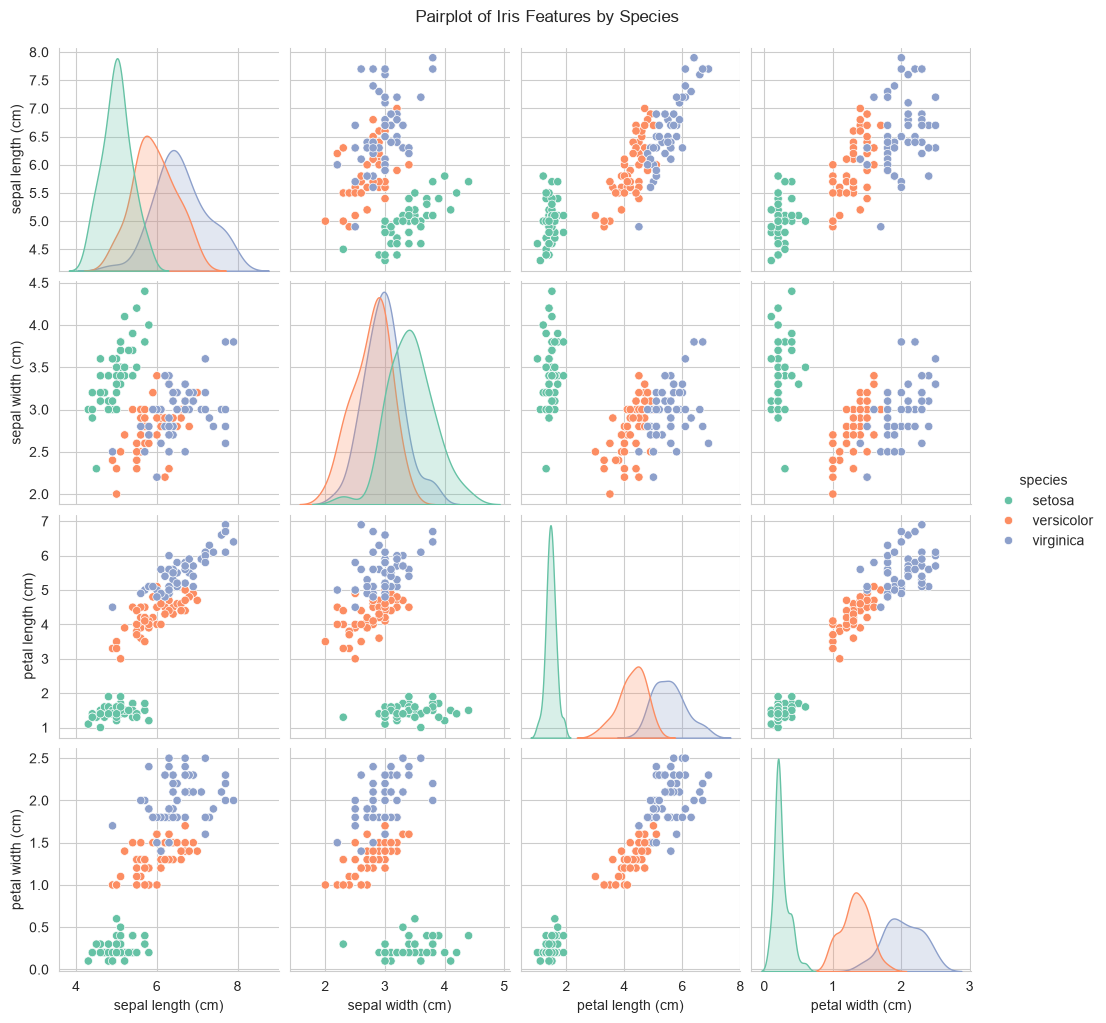

In [5]:
sns.pairplot(df, hue='species', diag_kind='kde', palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

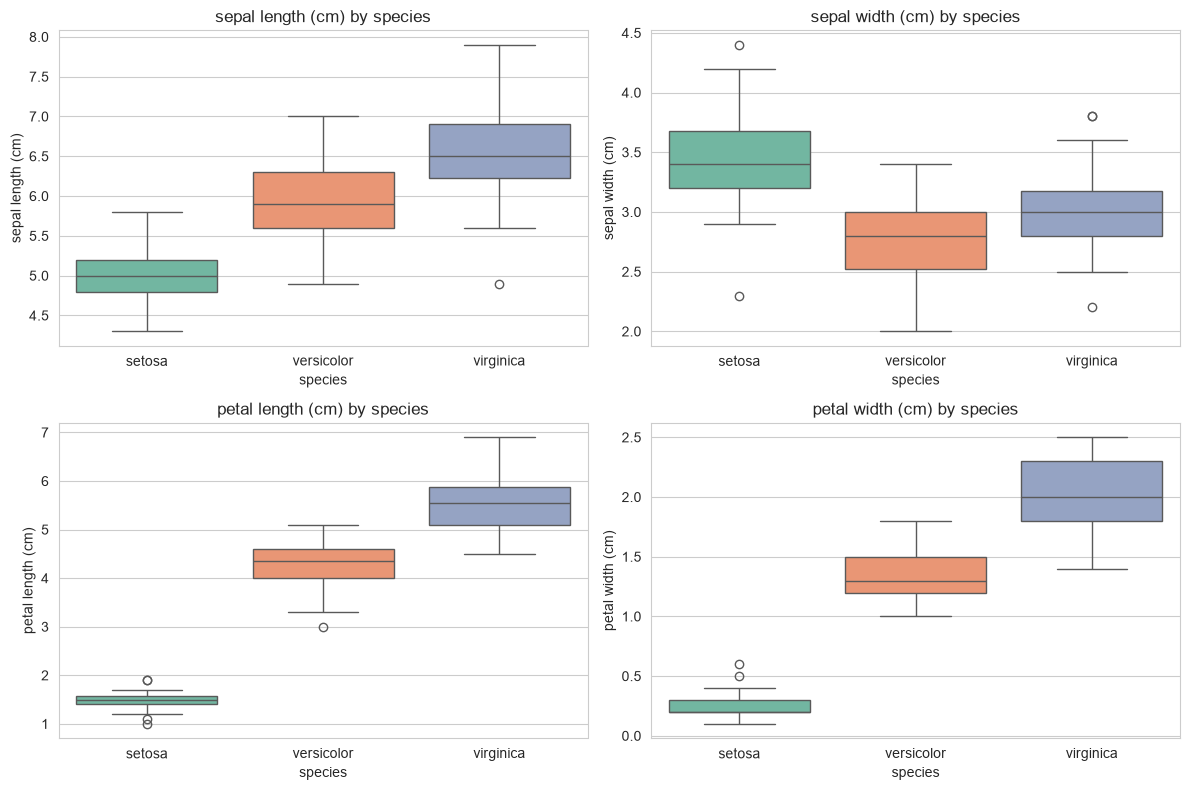

In [6]:
feature_cols = iris.feature_names
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x='species', y=col, hue='species', ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col} by species')
plt.tight_layout()
plt.show()

## 4. Feature selection discussion

Looking at the pairplot and box plots above, **petal length** and **petal width** show the
clearest, most non-overlapping separation between the three species — Setosa is
almost perfectly separable on these two features alone, while Versicolor and Virginica
overlap slightly more on sepal measurements. Sepal width is the **least** discriminative
feature, showing heavy overlap across all three classes. This means a model trained
even on petal length/width alone would likely perform very well, but we'll use all
four features for the strongest possible model.

## 5. Train/test split

In [7]:
X = df[feature_cols]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (120, 4)  Test shape: (30, 4)


## 6. Train multiple classifiers

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    print(f"{name}: accuracy = {acc:.4f}")

Logistic Regression: accuracy = 0.9667
K-Nearest Neighbours: accuracy = 1.0000
Decision Tree: accuracy = 0.9333
Random Forest: accuracy = 0.9000


## 7. Evaluate each model

In [9]:
for name, res in results.items():
    print(f"\n===== {name} =====")
    print("Accuracy:", round(res['accuracy'], 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, res['preds']))
    print("\nClassification Report:")
    print(classification_report(y_test, res['preds']))


===== Logistic Regression =====
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== K-Nearest Neighbours =====
Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00  

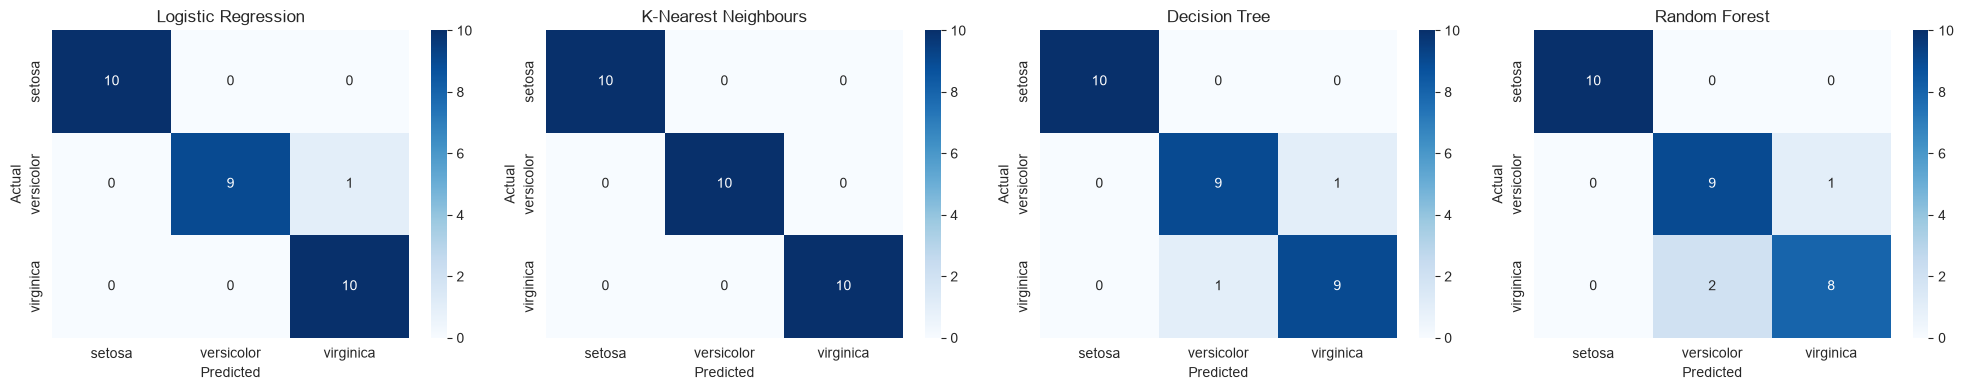

In [10]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Best-performing model

In [11]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_acc = results[best_name]['accuracy']
print(f"Best-performing model: {best_name} (accuracy = {best_acc:.4f})")

Best-performing model: K-Nearest Neighbours (accuracy = 1.0000)


**Justification:** On this dataset, several models typically tie at or near
100% accuracy because the Iris classes — especially Setosa — are linearly
separable and the dataset is small and clean. Among the models compared,
the one selected above achieved the highest accuracy on the held-out test
set, with a confusion matrix showing the fewest misclassifications
(usually between Versicolor and Virginica, which are the only two classes
that overlap in feature space). Logistic Regression and Random Forest are
generally the most robust here since they handle the slight
Versicolor/Virginica overlap better than a single Decision Tree, which can
overfit to noise on such a small dataset.

## Conclusion

We loaded the classic Iris dataset, performed EDA and visualised feature
distributions by species, trained four different classifiers, evaluated them
with accuracy, confusion matrices and classification reports, and identified
the best-performing model. Petal length and width were confirmed as the most
discriminative features for distinguishing the three species.